# Model KNN + Selection Personnel

**Indicateur de performance choisi : accuracy.**  
On utilise l'accuracy afin de représenter la proportion de bonne prédiction. cela permet aussi une comparaison facile entre les différents modeles.

## Réalisé par :

- [Samain Florian](https://github.com/NwaSet) — 2ème année, Intar D  
- [Ducourtieux Yohann](https://github.com/Nhanyo) — 2ème année, Intar D  

## Importation Des Librairie

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Chargement des données

In [12]:
selection_name = "P"
model_name = "KNN"

df_X_train = pd.read_csv(f"../../data/selected/X_train_{selection_name}.csv")
df_X_test = pd.read_csv(f"../../data/selected/X_test_{selection_name}.csv")

df_y_train = pd.read_csv("../../data/pre_processed/y_train.csv")
df_y_test = pd.read_csv("../../data/pre_processed/y_test.csv")

y_train = df_y_train.values.ravel()
y_test = df_y_test.values.ravel()

print("X_train shape :", df_X_train.shape)
print("X_test shape  :", df_X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

X_train shape : (1041, 14)
X_test shape  : (261, 14)
y_train shape : (1041,)
y_test shape  : (261,)


## 2. Modèle KNN simple

On entraîne d’abord un modèle de base pour avoir un premier point de comparaison.


In [13]:
knn = KNeighborsClassifier()

knn.fit(df_X_train, y_train)

y_train_pred = knn.predict(df_X_train)
y_test_pred = knn.predict(df_X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Accuracy train :", round(train_accuracy, 2))
print("Accuracy test  :", round(test_accuracy, 2))

Accuracy train : 0.83
Accuracy test  : 0.76


### Interprétation

on vois que la différence d'accuracy entre le train et le test est assez minime, ce qui veux dire que le model généralise assez bien les prédictions.

## 3. Validation croisée

La cross validation permet d’évaluer plus proprement la stabilité du modèle sur le jeu d’entraînement.


In [14]:
cv_scores = cross_val_score(knn, df_X_train, y_train, cv=5, scoring="accuracy")

print("Scores CV :", np.round(cv_scores, 2))
print("Accuracy CV moyenne :", round(cv_scores.mean(), 2))

Scores CV : [0.78 0.74 0.75 0.76 0.71]
Accuracy CV moyenne : 0.75


### Interprétation
- Une moyenne élevée est un bon signe.
- Un écart-type faible signifie que le modèle est assez stable selon les folds.
- Un écart-type élevé peut montrer que les performances varient beaucoup d’un sous-ensemble à l’autre.


## 4. Optimisation des hyperparamètres

On cherche les meilleurs paramètres avec `GridSearchCV`.


In [15]:
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(df_X_train, y_train)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score CV    :", round(grid.best_score_, 2))

Meilleurs paramètres : {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Meilleur score CV    : 0.75


### Interprétation
Les meilleurs hyperparamètres sont ceux qui donnent la meilleure accuracy moyenne en validation croisée sur le train.


## 5. Évaluation du meilleur modèle


In [16]:
best_knn = grid.best_estimator_

y_train_pred_best = best_knn.predict(df_X_train)
y_test_pred_best = best_knn.predict(df_X_test)

train_accuracy_best = accuracy_score(y_train, y_train_pred_best)
test_accuracy_best = accuracy_score(y_test, y_test_pred_best)

print("Accuracy train optimisé :", round(train_accuracy_best, 2))
print("Accuracy test optimisé  :", round(test_accuracy_best, 2))

Accuracy train optimisé : 0.84
Accuracy test optimisé  : 0.75


## Interprétation

on se rend compte que l'accuracy du train et du test reste semblable au premier test, on peut donc penser que le model était déjà bon au premier test.

## 6. Matrice de confusion


In [17]:
cm = confusion_matrix(y_test, y_test_pred_best)
cm

array([[131,  31],
       [ 35,  64]])

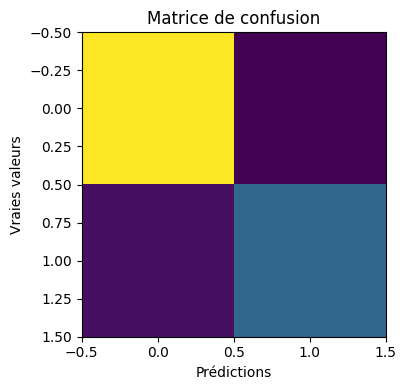

In [18]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)
ax.set_title("Matrice de confusion")
ax.set_xlabel("Prédictions")
ax.set_ylabel("Vraies valeurs")

# for i in range(cm.shape[0]):
#     for j in range(cm.shape[1]):
#         ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

### Interprétation
La matrice de confusion permet de voir plus concrètement les bonnes et mauvaises classifications du modèle.


In [19]:
results_row = pd.DataFrame([{
    "Selection": selection_name,
    "Model": model_name,
    "Accuracy_train": round(train_accuracy_best, 4),
    "Accuracy_test": round(test_accuracy_best, 4),
    "Accuracy_cv_mean": round(grid.best_score_, 4),
    "CV_std": round(cv_scores.std(), 4),
    "Best_params": str(grid.best_params_)
}])

results_row

,Selection,Model,Accuracy_train,Accuracy_test,Accuracy_cv_mean,CV_std,Best_params
0,P,KNN,0.8377,0.7471,0.7541,0.0239,"{'metric': 'manhattan', 'n_neighbors': 5, 'wei..."


## 9. Conclusion et réflexion

### Conclusion possible
Le modèle KNN a été entraîné sur la sélection choisie, puis optimisé par recherche d’hyperparamètres.  
La comparaison entre les scores train, test et validation croisée permet de juger si le modèle généralise correctement.

### Réflexion originale possible
- Le KNN est-il vraiment le meilleur choix pour ce dataset, sachant qu’il dépend fortement de la distance entre les observations ?
- Le résultat change-t-il beaucoup selon la sélection de variables choisie ?
- Une sélection de variables plus réduite peut-elle améliorer la généralisation du modèle ?
- Le modèle le plus performant en accuracy est-il forcément le plus pertinent à retenir ?
